### How to Adapt to Regime Changes

In [2]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import xlabel
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Goal

Go from a strategy that is not adaptive to regime changes to one that does.

4 ways to handle regime shifts
1. Sliding window
2. Encoding memory
3. Online learning
4. Policy gradient reinforcement learning

### What is a regime change?
We need some way to define what a regime change is mathematically.
It can be modeled as when as when a time series exhibits non-stationary dynamics (its behaviour is changing).

### What is stationarity?
Stationarity is when a time series has constant statistical properties, meaning that they do not change over time.
These properties are:
1. Mean
2. Variance
3. Skewness
4. Kurtosis

In [3]:
ethusdt = pd.read_csv("ETH-USDT-1d.csv")
ethusdt['t'] = pd.to_datetime(ethusdt['t'])
ethusdt.set_index('t', inplace=True)
ethusdt['close_return'] = ethusdt['c'].pct_change()
ethusdt

,Unnamed: 0,T,s,i,o,c,h,l,v,n,close_return
t,,,,,,,,,,,
2020-08-19,0,2020-08-19 23:59:59.999,ETH,1d,421.92,407.46,426.75,393.25,978339.69221,455992,NaN
2020-08-20,1,2020-08-20 23:59:59.999,ETH,1d,407.46,415.94,418.98,402.07,663555.73445,322537,0.020812
2020-08-21,2,2020-08-21 23:59:59.999,ETH,1d,415.94,387.97,418.68,385.10,860998.72560,414222,-0.067245
2020-08-22,3,2020-08-22 23:59:59.999,ETH,1d,387.93,395.24,397.04,379.92,643235.76543,305450,0.018739
2020-08-23,4,2020-08-23 23:59:59.999,ETH,1d,395.23,390.71,396.95,383.15,445317.81989,222729,-0.011461
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-12,2092,2026-05-12 23:59:59.999,ETH,1d,2339.88,2274.96,2340.85,2256.27,252981.10820,2520381,-0.027741
2026-05-13,2093,2026-05-13 23:59:59.999,ETH,1d,2274.97,2258.65,2323.36,2234.13,258455.72990,2145600,-0.007169
2026-05-14,2094,2026-05-14 23:59:59.999,ETH,1d,2258.66,2283.25,2319.33,2238.64,256680.83590,2730407,0.010891


<Axes: >

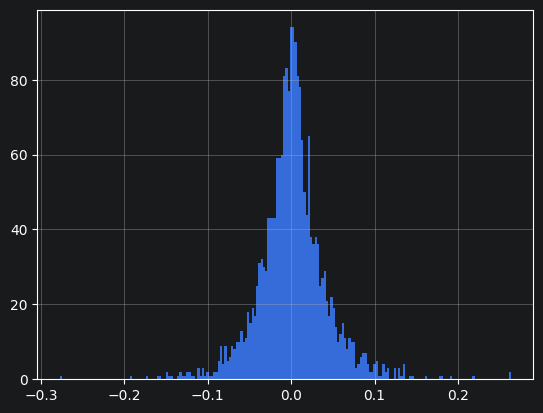

In [4]:
ethusdt['close_return'].hist(bins=200)

In [5]:
ethusdt.aggregate({'close_return': ['mean', 'std', 'skew', 'kurt']})

,close_return
mean,0.001649
std,0.041223
skew,0.186773
kurt,4.671933


Are ETH returns stationary?

In [6]:
ethusdt.groupby(ethusdt.index.year).aggregate({'close_return': ['mean', 'std', 'skew', pd.Series.kurtosis]})

close_return                              
             mean       std      skew      kurt
t                                              
2020     0.005370  0.043403 -0.423503  0.621057
2021     0.006022  0.056681  0.019802  3.610217
2022    -0.002035  0.045399 -0.041314  2.541228
2023     0.002068  0.024523  0.512947  2.537440
2024     0.001606  0.033942  0.749306  4.081904
2025     0.000441  0.039230  0.551293  4.091410
2026    -0.001628  0.035956  0.042086  3.257832

<Axes: xlabel='t'>

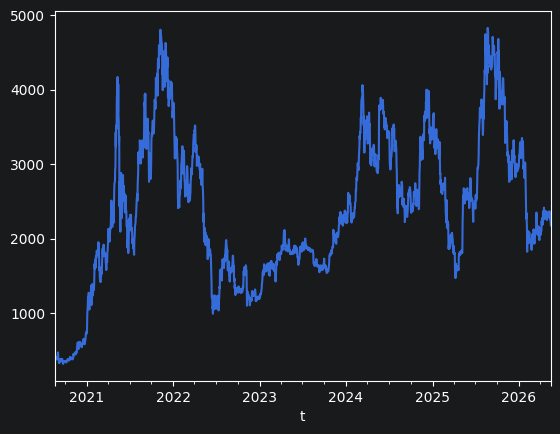

In [7]:
ethusdt['c'].plot()

### How to Handle Non-stationarity in Supervised Learning

Let's build a model to predict future returns using the current return. This is called a auto-regressive model.

$r_{t+1} = w * r_t + b$

In [8]:
ethusdt['close_log_return'] = np.log(ethusdt['c']/ethusdt['c'].shift())
ethusdt['close_log_return_lag_1'] = ethusdt['close_log_return'].shift()

In [9]:
def backtest_model(df, features, target, test_split=0.25):
    df = df.dropna()
    df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)

    X_train, X_test, y_train, y_test = df_train[features], df_test[features], df_train[target], df_test[target]

    model = LinearRegression()
    model.fit(X_train, y_train)
    print(model.coef_, model.intercept_)

    backtest = df.copy()
    backtest['y_hat'] = model.predict(backtest[features])
    backtest['signal'] = np.sign(backtest['y_hat'])
    backtest['trade_log_return'] = backtest['close_log_return'] * backtest['signal']
    backtest['cum_trade_log_return'] = backtest['trade_log_return'].cumsum()
    backtest['cum_trade_log_return'].plot()

    return model, backtest

[-0.05219562] 0.0015173243832486802


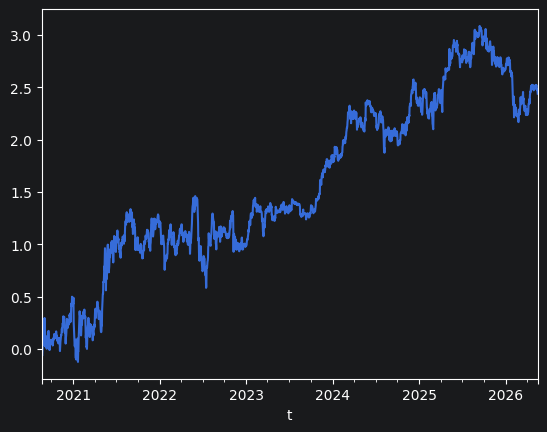

In [10]:
model, backtest = backtest_model(ethusdt, ['close_log_return_lag_1'], 'close_log_return')

$f(x) = -0.05219562 * x + 0.0015173243832486802$

<Axes: xlabel='t'>

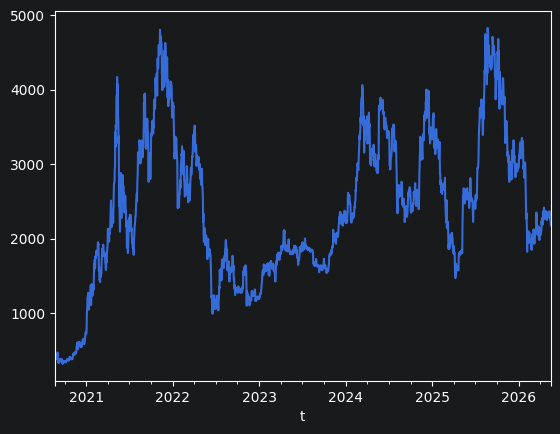

In [11]:
backtest['c'].plot()

In [12]:
backtest['signal'].value_counts()

signal
 1.0    1707
-1.0     388
Name: count, dtype: int64

### 1. Sliding Window

```
RAW TIME SERIES DATA
[t0][t1][t2][t3][t4][t5][t6][t7][t8][t9]

TRAINING SAMPLE 1 (Step 0)
Features (x): [t0][t1][t2][t3]
Target (y): [t4]

TRAINING SAMPLE 2 (Step 1) - Window slides forward by 1
Features (x): [t1][t2][t3][t4]
Target (y): [t5]

TRAINING SAMPLE 3 (Step 2) - Window slides forward again
Features (x): [t2][t3][t4][t5]
Target (y): [t6]

MATRIX VIEW FOR ML ALGORITHM (X -> y):
Row 0: [t0][t1][t2][t3] -> [t4]
Row 1: [t1][t2][t3][t4] -> [t5]
Row 2: [t2][t3][t4][t5] -> [t6]
Row 3: [t3][t4][t5][t6] -> [t7]
```

### 2. Encoding memory

Take raw, noisy sequence of past returns and compresses it into a single, continuous hidden state.

In [13]:
ethusdt['close_log_return_ma_lag_1'] = ethusdt['close_log_return_lag_1'].rolling(40).mean()
ethusdt

,Unnamed: 0,T,s,i,o,c,h,l,v,n,close_return,close_log_return,close_log_return_lag_1,close_log_return_ma_lag_1
t,,,,,,,,,,,,,,
2020-08-19,0,2020-08-19 23:59:59.999,ETH,1d,421.92,407.46,426.75,393.25,978339.69221,455992,NaN,NaN,NaN,NaN
2020-08-20,1,2020-08-20 23:59:59.999,ETH,1d,407.46,415.94,418.98,402.07,663555.73445,322537,0.020812,0.020598,NaN,NaN
2020-08-21,2,2020-08-21 23:59:59.999,ETH,1d,415.94,387.97,418.68,385.10,860998.72560,414222,-0.067245,-0.069613,0.020598,NaN
2020-08-22,3,2020-08-22 23:59:59.999,ETH,1d,387.93,395.24,397.04,379.92,643235.76543,305450,0.018739,0.018565,-0.069613,NaN
2020-08-23,4,2020-08-23 23:59:59.999,ETH,1d,395.23,390.71,396.95,383.15,445317.81989,222729,-0.011461,-0.011528,0.018565,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-12,2092,2026-05-12 23:59:59.999,ETH,1d,2339.88,2274.96,2340.85,2256.27,252981.10820,2520381,-0.027741,-0.028133,-0.013330,0.002228
2026-05-13,2093,2026-05-13 23:59:59.999,ETH,1d,2274.97,2258.65,2323.36,2234.13,258455.72990,2145600,-0.007169,-0.007195,-0.028133,0.002516
2026-05-14,2094,2026-05-14 23:59:59.999,ETH,1d,2258.66,2283.25,2319.33,2238.64,256680.83590,2730407,0.010891,0.010833,-0.007195,0.002377


[0.15680071] 0.0012826229395797469


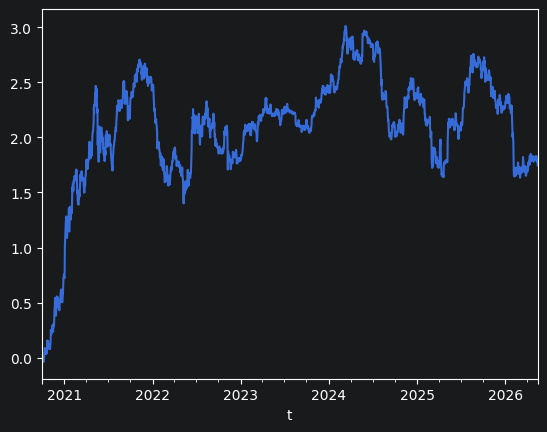

In [14]:
model, backtest = backtest_model(ethusdt, ['close_log_return_ma_lag_1'], 'close_log_return')

In [15]:
backtest['signal'].value_counts()

signal
 1.0    1860
-1.0     196
Name: count, dtype: int64

Modeling Relative Memory

[-0.05274912  0.21108588] 0.0012859237064335568


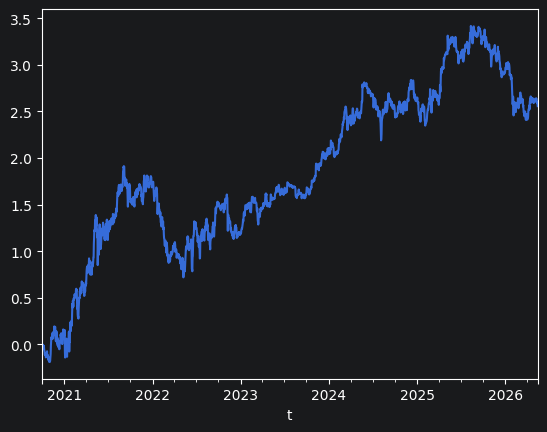

In [16]:
model, backtest = backtest_model(ethusdt, ['close_log_return_lag_1', 'close_log_return_ma_lag_1'], 'close_log_return')

<Axes: xlabel='t'>

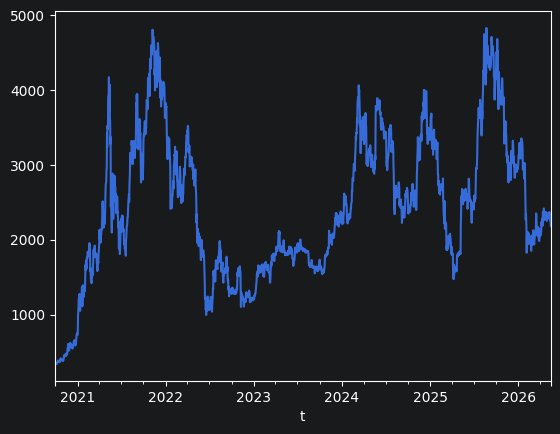

In [17]:
backtest['c'].plot()

In [18]:
backtest['signal'].value_counts()

signal
 1.0    1590
-1.0     466
Name: count, dtype: int64

### 3. Online Learning

The Passive Aggressive Regressor is on online linear regression model that updates its weights sample by sample, remaining completely passive is its prediction error falls within an acceptable, user-defined error margin $\epsilon$. If the error exceeds that margin, it reacts aggressively by making the smallest possible adjustment to its weight vector to accurately fit that new point, capped by a regularization parameter C to prevent sudden noise from ruining past learning.

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# prepare data stream
df_clean = ethusdt.dropna()
features = ['close_log_return_lag_1']
target = 'close_log_return'

X_stream = df_clean[features].to_numpy()
y_stream = df_clean[target].to_numpy()

# initialize updated online learning components
# using SGDRegressor configured for native passive aggressive updates
model = SGDRegressor(
    loss='epsilon_insensitive',
    epsilon=0.0002, # the acceptable error margin
    penalty=None, # pure PA doesn't use L1/L2 shrinkage penalties
    learning_rate='pa1', # uses pa-1 update rules
    eta0=0.01,
)
scaler = StandardScaler()

records = [] # list to collect structural and evaluation records row-by-row

# pure streaming loop
for t in range(len(X_stream)):
    x_t = X_stream[t].reshape(1,-1)
    y_t = np.array([y_stream[t]])

    # scale feature vector incrementally based on live variance shifts
    scaler.partial_fit(x_t)
    x_t_scaled = scaler.transform(x_t)

    # predict before updating weights
    if t == 0:
        pred_y = 0.0 # cold start initialization
    else:
        pred_y = model.predict(x_t_scaled)[0]

    # evaluate directional accuracy
    if t > 0 and y_t[0] != 0 and pred_y != 0:
        sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"
    else:
        sign_match = "WARMUP"
    # update weights dynamically via SGD single-sample steps
    model.partial_fit(x_t_scaled, y_t)

    # extract structural components safely from SGDRegressor
    current_weight = model.coef_[0]
    current_bias = model.intercept_[0]

    # calculate signal and if won or not in the tick
    signal = np.sign(pred_y)
    trade_log_return = signal * y_t[0]

    # record the complete state context at this tick
    if sign_match != "WARMUP":
        records.append({
            'tick': t,
            'lag_1_x': x_t[0][0],
            'true_y': y_t[0],
            'pred_y_hat': pred_y,
            'sign_match': sign_match,
            'model_weight': current_weight,
            'model_bias': current_bias,
            'signal': signal,
            'trade_log_return': trade_log_return,
            'is_won': np.sign(y_t[0]) == np.sign(pred_y),
        })

# convert records to pandas df
df_results = pd.DataFrame(records)
df_results.set_index('tick', inplace=True)
df_results['cum_trade_log_return'] = df_results['trade_log_return'].cumsum()

# calculate directional hit rate
evaluated_mask = df_results['sign_match'].isin(['YES', 'NO'])
if evaluated_mask.sum() > 0:
    hit_rate = (df_results[evaluated_mask]['sign_match'] == 'YES').mean() * 100
    print(f"/nHit rate: {hit_rate:.2f}%")

df_results

/nHit rate: 49.39%


,lag_1_x,true_y,pred_y_hat,sign_match,model_weight,model_bias,signal,trade_log_return,is_won,cum_trade_log_return
tick,,,,,,,,,,
3,-0.019589,-0.020761,-0.012343,YES,0.008598,-0.015448,-1.0,0.020761,True,0.020761
4,-0.020761,0.001012,-0.024172,NO,-0.001548,-0.005448,-1.0,-0.001012,False,0.019749
5,0.001012,0.018388,-0.006224,NO,0.003468,0.004552,-1.0,-0.018388,False,0.001361
6,0.018388,0.003541,0.009413,YES,-0.000579,0.001666,1.0,0.003541,True,0.004902
7,0.003541,-0.037074,0.001460,NO,-0.004138,-0.008334,1.0,-0.037074,False,-0.032171
...,...,...,...,...,...,...,...,...,...,...
2051,-0.013330,-0.028133,0.006679,NO,-0.012697,-0.008943,1.0,-0.028133,False,0.881779
2052,-0.028133,-0.007195,0.000053,NO,-0.005611,-0.018943,1.0,-0.007195,False,0.874584
2053,-0.007195,0.010833,-0.017835,NO,-0.007586,-0.008943,-1.0,-0.010833,False,0.863751


In [20]:
df_results['signal'].value_counts()

signal
-1.0    1031
 1.0    1022
Name: count, dtype: int64

<Axes: xlabel='tick'>

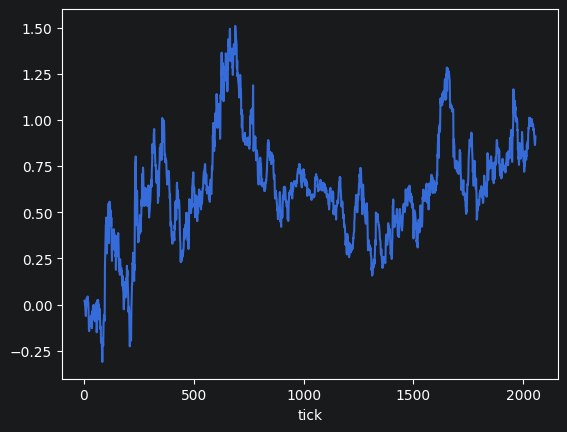

In [21]:
df_results['cum_trade_log_return'].plot()

<Axes: xlabel='t'>

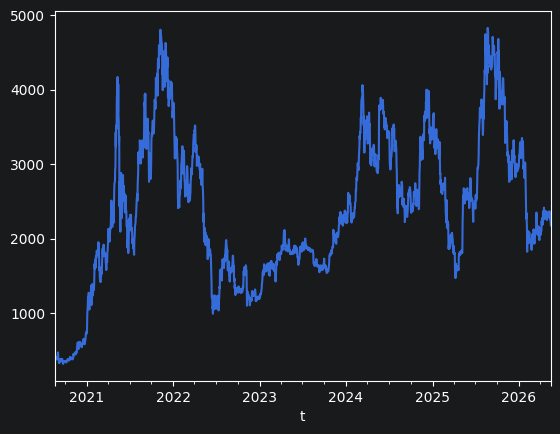

In [22]:
ethusdt['c'].plot()

### Policy Gradient Reinforcement Learning
We can formulate trading as a partially observable 2-arm bandit problem.

We don't know what the true distribution is, so it is only partially observable.

https://people.cs.umass.edu/~barto/courses/cs687/williams92simple.pdf

####  Partially Observable Stationary 2-armed Bandit
Look at a bandit where the odds are stationary as a warmup to RL bandits.

In [23]:
"""
Deep RL bot learning a biased coin toss.

Game:
A coin has a static bias p = P(heads). Agent guesses heads (1) or tails (0).
Correct guess: +$1. Wrong guess: -$1.

Optimal policy:
Always guess the more likely side (NOT match the bias!).
If p > 0.5: always guess heads. -> expected reward/flip = 2p - 1
If p < 0.5: always guess tails. -> expected reward/flip = 1 - 2p

Method:
REINFORCE (vanilla policy gradient) with a tiny linear policy network. Sicne there's no real state, the input is a constant 1.0 and the network just learns a bias vector that defines a fixed action distribution.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

class StationaryBiasedCoin:
    """Stateless stationary biased-coin environment."""
    def __init__(self, p_heads=0.7):
        self.p_heads = p_heads

    def step(self, action):
        outcome = 1 if np.random.random() < self.p_heads else 0
        reward = 1.0 if action == outcome else -1.0
        return reward, outcome

class Policy(nn.Module):
    """
    Constant input -> logits over {tails=0, heads=1}.
    """
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 2)

    def forward(self, x):
        return self.fc(x)

In [24]:
def train(env, n_episodes=2000, lr=0.05, log_every=200, seed=0):
    strategy = Policy()
    optimizer = optim.Adam(strategy.parameters(), lr=lr)

    state = torch.tensor([1.0]) # constant dummy input
    rewards, p_heads_history = [], []

    for episode in range(n_episodes):
        # forward pass: sample an action from the current policy
        logits = strategy(state)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        # interact with environment
        reward, _ = env.step(action.item())

        # REINFORCE update: maximize E[log pi(a|s) * R] -> minimize negative of that
        loss = -log_prob * reward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # logging
        rewards.append(reward)
        with torch.no_grad():
            probs = torch.softmax(strategy(state), dim=-1)
            p_heads_history.append(probs[1].item())

        if (episode + 1) % log_every == 0:
            recent = np.mean(rewards[-log_every:])
            print(f"Episode {episode+1:>5d} | P(guess heads)={probs[1]:.3f} "
                  f"| Average reward (last {log_every})={recent:+.3f}")

    return strategy, rewards, p_heads_history


Episode   200 | P(guess heads)=0.860 | Average reward (last 200)=+0.130
Episode   400 | P(guess heads)=0.939 | Average reward (last 200)=+0.180
Episode   600 | P(guess heads)=0.973 | Average reward (last 200)=+0.380
Episode   800 | P(guess heads)=0.983 | Average reward (last 200)=+0.360
Episode  1000 | P(guess heads)=0.990 | Average reward (last 200)=+0.390
Episode  1200 | P(guess heads)=0.990 | Average reward (last 200)=+0.240
Episode  1400 | P(guess heads)=0.993 | Average reward (last 200)=+0.340
Episode  1600 | P(guess heads)=0.989 | Average reward (last 200)=+0.460
Episode  1800 | P(guess heads)=0.994 | Average reward (last 200)=+0.380
Episode  2000 | P(guess heads)=0.994 | Average reward (last 200)=+0.340

--- RESULTS ---
True coin bias:                     P(heads)=0.7
Learned policy:                     P(guess heads) = 0.994
Optimal expected reward/flip:       +0.400
Average reward (last 500 episodes): +0.372

Saved plot to coin-toss-training.png


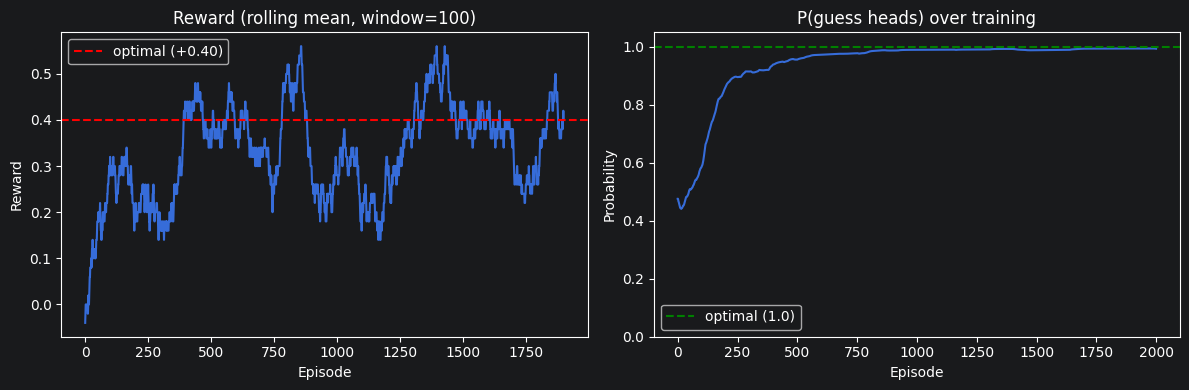

In [25]:
P_TRUE = 0.7
env = StationaryBiasedCoin(P_TRUE)
policy, rewards, p_heads_history = train(env, n_episodes=2000, lr=0.01)

with torch.no_grad():
    final = torch.softmax(policy(torch.tensor([1.0])), dim=-1)

optimal = 2 * max(P_TRUE, 1 - P_TRUE) - 1
print("\n--- RESULTS ---")
print(f"True coin bias:                     P(heads)={P_TRUE}")
print(f"Learned policy:                     P(guess heads) = {final[1]:.3f}")
print(f"Optimal expected reward/flip:       {optimal:+.3f}")
print(f"Average reward (last 500 episodes): {np.mean(rewards[-500:]):+.3f}")

# plot learning curves
try:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    window = 100
    smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
    ax1.plot(smoothed)
    ax1.axhline(optimal, ls='--', c='r', label=f'optimal ({optimal:+.2f})')
    ax1.set(title=f'Reward (rolling mean, window={window})',
            xlabel='Episode', ylabel='Reward')
    ax1.legend()
    ax2.plot(p_heads_history)
    ax2.axhline(1.0, ls='--', c='g', label='optimal (1.0)')
    ax2.set(title='P(guess heads) over training',
            xlabel='Episode', ylabel='Probability', ylim=(0, 1.05))
    ax2.legend()
    plt.tight_layout()
    plt.savefig('coin-toss-training.png', dpi=100)
    print("\nSaved plot to coin-toss-training.png")
except ImportError:
    pass
